# Coefficient Comparison Notebook

### Data-Generation

The Case 1 signals are designed to mimic noisy, partially correlated sensors:


In [1]:
from __future__ import annotations
print("Loading production libraries...")
import argparse, json, time, itertools, importlib.util, math, os, re
from pathlib import Path
import numpy as np
import pandas as pd
import sys
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.transforms import Bbox
try:
    from IPython.display import display
except ImportError:
    display = None
from sklearn.metrics import roc_curve, auc
from datetime import datetime
from typing import Dict, Iterable, List, Optional, Sequence, Tuple
from cutlass import (
    CutlassLogisticCV,
    Rectifier,
    StandardScaler,
    calculate_youden_j,
    precision_recall_curve,
    roc_auc_score,
)
from cutlass.pipeline import Pipeline


Loading production libraries...


### General helpers

In [2]:
# ---------- simple function to print timestamp to console -----------
def timestamp():
    strtime = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"({strtime})")
# ---------- robust import by file path (works in scripts and notebooks) ----------
def _find_scripts_dir() -> Path:
    if "__file__" in globals():
        anchors = [Path(__file__).resolve().parent]
    else:
        anchors = [Path.cwd().resolve()]
    for anchor in anchors:
        for candidate in (anchor, *anchor.parents):
            scripts_dir = candidate / "scripts"
            if scripts_dir.is_dir():
                return scripts_dir
    raise FileNotFoundError("Could not locate the repository 'scripts' directory from the current working directory.")
def _find_notebooks_dir() -> Path:
    if "__file__" in globals():
        anchors = [Path(__file__).resolve().parent]
    else:
        anchors = [Path.cwd().resolve()]
    for anchor in anchors:
        for candidate in (anchor, *anchor.parents):
            notebooks_dir = candidate / "notebooks"
            if notebooks_dir.is_dir():
                return notebooks_dir
    raise FileNotFoundError("Could not locate the repository 'notebooks' directory from the current working directory.")
def _find_legacy_case1_scripts_dir() -> Path:
    if "__file__" in globals():
        anchors = [Path(__file__).resolve().parent]
    else:
        anchors = [Path.cwd().resolve()]
    seen = set()
    for anchor in anchors:
        for root in (anchor, *anchor.parents):
            for candidate in (root / 'cutlass_demo_v0' / 'scripts', root.parent / 'cutlass_demo_v0' / 'scripts'):
                key = str(candidate.resolve()) if candidate.exists() else str(candidate)
                if key in seen:
                    continue
                seen.add(key)
                if candidate.is_dir():
                    return candidate
    raise FileNotFoundError("Could not locate the legacy Case 1 scripts directory under 'cutlass_demo_v0/scripts'.")
SCRIPTS_DIR = _find_scripts_dir()
NOTEBOOKS_DIR = _find_notebooks_dir()
NOTEBOOK_FIGURES_DIR = NOTEBOOKS_DIR / "Figures"
NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LEGACY_CASE1_SCRIPTS_DIR = _find_legacy_case1_scripts_dir()
if str(LEGACY_CASE1_SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(LEGACY_CASE1_SCRIPTS_DIR))
GD_PATH = LEGACY_CASE1_SCRIPTS_DIR / "case_1_simple_script_gd_v9.py"
SK_PATH = LEGACY_CASE1_SCRIPTS_DIR / "case_1_simple_script_scikit_fast_v6.py"
SYN_PATH = LEGACY_CASE1_SCRIPTS_DIR / "sensor_generate - commented.py"
def _import_from_path(name: str, path: Path):
    spec = importlib.util.spec_from_file_location(name, str(path))
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    assert spec.loader is not None
    spec.loader.exec_module(mod)
    return mod


In [3]:
print('Legacy Case 1 synthetic scripts:', GD_PATH.parent)
print('Legacy generator:', SYN_PATH)
print('Legacy cutlass pipeline:', GD_PATH)



Legacy Case 1 synthetic scripts: C:\Users\jason\ODU\cutlass_demo_v0\scripts
Legacy generator: C:\Users\jason\ODU\cutlass_demo_v0\scripts\sensor_generate - commented.py
Legacy cutlass pipeline: C:\Users\jason\ODU\cutlass_demo_v0\scripts\case_1_simple_script_gd_v9.py


In [4]:
print("Loading custom libraries ", end=""); timestamp()
syn = _import_from_path("sensor_generate_legacy_case1", SYN_PATH)
skcase = _import_from_path("case_1_simple_script_scikit_fast_v6", SK_PATH)
gdcase = _import_from_path("case_1_simple_script_gd_v9", GD_PATH)

# convenience aliases to functions/classes
generate_synth = syn.generate_synthetic_dataset_nexamples
sklearn_build_rectified_external_cv = skcase.sklearn_build_rectified_external_cv
sklearn_build_raw_external_cv = skcase.sklearn_build_raw_external_cv

RESP = "INDC"
EXCL = {"X", "UIC", "iDate", "iDate.x", "iDate.y", "class", "cols", "year"}
LABELS = ["V5TM10", "V6TM6", "V9TM1", "V10TM0", "V15TM5", "V25TM3", "V30TM7"]
youdenJ = gdcase.calculate_youden_j
EXCLUDE_FOR_RECT = sorted(set(EXCL) | {RESP})



Loading custom libraries (2026-04-04 17:23:36)


### Plotting + Reporting helpers

In [5]:
def plot_sorted(prob, y_bool, title, h=0.5):
    # Primary key: probability (ascending). Tie-break on label so negatives come first.
    order = np.lexsort((y_bool.astype(int), prob))
    fig, ax = plt.subplots()
    ax.scatter(np.arange(prob.size), prob[order], c=y_bool[order], s=6, alpha=0.8, rasterized=True)
    ax.axhline(h, linestyle="--", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Sorted Examples (tie-broken)")
    ax.set_ylabel("Model Response")
    ax.set_ylim(0.0, 1.0)
    fig.tight_layout()
    return fig


def plot_sorted_tiebreak(prob, y_bool, title, h=0.5):
    # Sort by probability; for exact ties put negatives first.
    order = np.lexsort((~y_bool, prob))
    fig, ax = plt.subplots()
    ax.scatter(np.arange(prob.size), prob[order], c=y_bool[order], s=6, alpha=0.8, rasterized=True)
    ax.axhline(h, linestyle="--", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Sorted Examples (tie-broken: negatives first)")
    ax.set_ylabel("Model Response")
    ax.set_ylim(0.0, 1.0)
    fig.tight_layout()
    return fig


def _display_figure(fig) -> bool:
    backend = matplotlib.get_backend().lower()
    notebook_backend = any(key in backend for key in ("inline", "nbagg", "ipympl", "widget"))
    if notebook_backend and display is not None:
        display(fig)
        return True
    return False


def maybe_show_or_save(fig, title: str, save_dir: Optional[str], show_each: bool):
    backend = matplotlib.get_backend().lower()
    interactive = any(key in backend for key in ("qt", "tk", "wx", "gtk", "macosx", "nbagg", "ipympl"))
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        safe = re.sub(r"[^A-Za-z0-9_.-]+", "_", title).strip("_")
        out = os.path.join(save_dir, f"{safe}.png")
        fig.savefig(out, dpi=150)
        print(f"[saved] {out}")
        shown = _display_figure(fig)
        if (not shown) and interactive:
            if show_each:
                try:
                    fig.canvas.manager.set_window_title(title)
                except Exception:
                    pass
                plt.show()
            else:
                fig.show()
        plt.close(fig)
        return

    if interactive:
        if show_each:
            try:
                fig.canvas.manager.set_window_title(title)
            except Exception:
                pass
            plt.show()
        else:
            fig.show()
        return

    auto_dir = os.path.abspath("./figs")
    os.makedirs(auto_dir, exist_ok=True)
    safe = re.sub(r"[^A-Za-z0-9_.-]+", "_", title).strip("_")
    out = os.path.join(auto_dir, f"{safe}.png")
    fig.savefig(out, dpi=150)
    print(f"[non-interactive backend: saved] {out}")
    plt.close(fig)


def _natural_vtm_key(name: str):
    """
    Parse names like 'V5TM10' -> (5, 10, 'V5TM10') for a natural sort by variable then lag.
    Unparsable names go to the end.
    """
    match = re.match(r"^V(\d+)TM(\d+)$", name)
    if match:
        return (int(match.group(1)), int(match.group(2)), name)
    return (10**9, 10**9, name)


def coefficient_series_only(pipe: Pipeline, feature_names: List[str], *, sort_for_plot: bool = False) -> pd.Series:
    """
    Return coefficients as a Series indexed by feature_names.
    If sort_for_plot=True, return a reordered copy that is easier to read for plotting.
    """
    lr = pipe.named_steps["lr"]
    coef = lr.coef_.ravel()
    if coef.shape[0] != len(feature_names):
        raise ValueError(f"coef length {coef.shape[0]} != feature_names length {len(feature_names)}")
    series = pd.Series(coef, index=feature_names)
    if sort_for_plot:
        series = series.sort_index(key=lambda idx: [_natural_vtm_key(name) for name in idx])
    return series


def plot_coeff_bars(
    beta: pd.Series,
    title: str,
    highlights: Optional[List[str]] = None,
    *,
    annotate: bool = True,
    fontsize: int = 9,
    exact_match: bool = True,
):
    """Bar plot of coefficients with optional highlight labels."""
    fig = plt.figure(num=title)
    ax = fig.gca()

    x = np.arange(len(beta))
    ax.bar(x, beta.values, linewidth=1)

    max_abs = np.nanmax(np.abs(beta.values)) if len(beta) else 1.0
    ylim = max(max_abs * 1.3, 0.5)
    ax.set_ylim(-0.1 * ylim, ylim)

    if annotate and highlights:
        if exact_match:
            patterns = [re.compile(rf"^{re.escape(pat)}$") for pat in highlights]

            def is_hit(name: str) -> bool:
                return any(rx.match(name) for rx in patterns)
        else:

            def is_hit(name: str) -> bool:
                return any(pat in name for pat in highlights)

        for idx, name in enumerate(beta.index):
            if is_hit(name):
                val = beta.values[idx]
                offset = 0.04 * ylim
                y_coord = val + (offset if val >= 0 else -offset)
                valign = "bottom" if val >= 0 else "top"
                ax.text(idx, y_coord, name, rotation=90, ha="center", va=valign, fontsize=fontsize)

    ax.set_xticks([])
    ax.set_title(title)
    fig.tight_layout()
    return fig


def plot_coeff_comparison_panels(
    coeff_specs: Sequence[Dict[str, object]],
    title: str,
    highlights: Optional[List[str]] = None,
    *,
    fontsize: int = 18,
):
    """Plot aligned coefficient series in stacked panels that share the same feature axis."""
    if not coeff_specs:
        raise ValueError("coeff_specs must not be empty")

    feature_order = sorted(
        {name for spec in coeff_specs for name in spec["beta"].index},
        key=_natural_vtm_key,
    )
    x = np.arange(len(feature_order))

    color_cycle = [
        "#f4a261", "#ff99ff", "#a8dadc", "#bdb2a7", "#ffb3c1", "#9be564", "#4c78a8"
    ]
    highlight_colors = {
        name: color_cycle[i % len(color_cycle)] for i, name in enumerate(highlights or [])
    }
    highlight_positions = [feature_order.index(name) for name in (highlights or []) if name in feature_order]
    highlight_labels = [name for name in (highlights or []) if name in feature_order]

    fig, axes = plt.subplots(
        len(coeff_specs),
        1,
        sharex=True,
        figsize=(14, 3.2 * len(coeff_specs) + 1.2),
        gridspec_kw={"hspace": 0.08},
    )
    if len(coeff_specs) == 1:
        axes = [axes]

    for ax, spec in zip(axes, coeff_specs):
        beta = spec["beta"].reindex(feature_order, fill_value=0.0)
        vals = beta.to_numpy(dtype=float)
        max_abs = np.nanmax(np.abs(vals)) if len(vals) else 1.0
        ylim = max(max_abs * 1.15, 0.5)

        for pos, label in zip(highlight_positions, highlight_labels):
            ax.axvline(pos, color=highlight_colors[label], linewidth=1.5, alpha=0.7, zorder=0)

        ax.vlines(x, 0.0, vals, color="blue", linewidth=1.6, alpha=0.85)
        ax.axhline(0.0, color="blue", linewidth=0.9, alpha=0.85)
        ax.set_ylim(-ylim, ylim)
        ax.set_ylabel(str(spec["panel_label"]), fontsize=13)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.tick_params(axis="y", labelsize=10)

    axes[-1].spines["bottom"].set_visible(False)
    axes[-1].set_xticks(highlight_positions)
    axes[-1].set_xticklabels(highlight_labels, rotation=90, fontsize=fontsize)
    axes[-1].tick_params(axis="x", length=0, pad=10)

    fig.suptitle(title, fontsize=36, y=0.98)
    x_label = fig.supxlabel("Features", fontsize=40)
    fig.supylabel("Coefficient Values", fontsize=20, x=0.01)
    fig.subplots_adjust(left=0.12, bottom=0.28, top=0.88, hspace=0.08)
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    tick_bboxes = [
        label.get_window_extent(renderer=renderer)
        for label in axes[-1].get_xticklabels()
        if label.get_text()
    ]
    if tick_bboxes:
        tick_bbox_fig = Bbox.union(tick_bboxes).transformed(fig.transFigure.inverted())
        xlabel_bbox_fig = x_label.get_window_extent(renderer=renderer).transformed(fig.transFigure.inverted())
        x_label.set_y(max(0.01, tick_bbox_fig.y0 - xlabel_bbox_fig.height - 0.015))
    return fig

### Modeling helpers

In [6]:
def organize(df: pd.DataFrame) -> Dict[str, List[str]]:
    feats = [str(c) for c in df.columns if c not in EXCL and c != RESP]
    groups: Dict[str, List[str]] = {}
    for feat in feats:
        prefix = re.sub(r"\d+$", "", feat)
        groups.setdefault(prefix, []).append(feat)
    for prefix, cols in groups.items():
        numeric: List[Tuple[int, str]] = []
        non_numeric: List[str] = []
        for col in cols:
            match = re.search(r"(\d+)$", col)
            if match:
                numeric.append((int(match.group(1)), col))
            else:
                non_numeric.append(col)
        ordered = [name for _, name in sorted(numeric)]
        ordered.extend(non_numeric)
        groups[prefix] = ordered
    return groups


def _rectify_with_cutlass(
    df: pd.DataFrame,
    *,
    rectifier: Rectifier,
) -> pd.DataFrame:
    X_rect = rectifier.transform(df)
    rect_df = pd.DataFrame(X_rect, columns=rectifier.feature_names_, index=df.index)
    rect_df[RESP] = df[RESP].values
    return rect_df


def rectify_fast(
    df: pd.DataFrame,
    groups: Dict[str, Sequence[str]],
    *,
    rectifier: Optional[Rectifier] = None,
    sdfilter: Optional[float] = 3.0,
    snap: float = 0.001,
) -> Tuple[pd.DataFrame, Dict[str, Dict[str, Tuple[float, float]]], Rectifier]:
    if rectifier is None:
        rectifier = Rectifier(
            groups=groups,
            sdfilter=sdfilter,
            snap=snap,
            exclude_features=EXCLUDE_FOR_RECT,
        )
        X_rect = rectifier.fit_transform(
            df, df[RESP].astype(int).to_numpy(copy=False)
        )
        rect_df = pd.DataFrame(
            X_rect, columns=rectifier.feature_names_, index=df.index
        )
        rect_df[RESP] = df[RESP].values
    else:
        rect_df = _rectify_with_cutlass(df, rectifier=rectifier)
    return rect_df, rectifier.limits_, rectifier


def _is_binary_pm1(dfX: pd.DataFrame) -> bool:
    if dfX.empty:
        return True
    sample_cols = dfX.columns[: min(len(dfX.columns), 10)]
    vals = np.unique(dfX[sample_cols].to_numpy(dtype=np.float64, copy=False))
    return np.all(np.isin(vals, (-1, 1)))


def build_model(
    X: pd.DataFrame,
    y_col: str = RESP,
    cv: int = 3,
    cs: int | Sequence[float] = 15,
    use_scaler: Optional[bool] = None,
    solver: str = "hybrid",
    tol: float = 1e-4,
    max_iter: int = 2000,
    random_state: int = 42,
    cv_rule: str = "min",
    zero_clamp: float = 0.0,
    logic_polish: bool = True,
    logic_scale: float = 10.0,
    logic_target: Optional[float] = None,
    logic_maxk: Optional[int] = None,
    logic_rel_tol: float = 0.2,
    logic_plot: bool = True,
    logic_plot_dir: Optional[str] = None,
    logic_Ks_plot: Optional[Sequence[float]] = None,
    logic_k_policy: str = "global",
    logic_smooth_k: int = 7,
    logic_firstmin_drop: float = 0.05,
    logic_firstmin_frac: float = 0.5,
    logic_intercept: str = "mofk",
    logic_m: Optional[int] = None,
    logic_m_frac: Optional[float] = None,
    verbose: bool = True,
) -> Pipeline:
    Xonly = X.drop(columns=[y_col])
    y = X[y_col].astype(int).to_numpy(copy=False)

    if isinstance(cs, int):
        Cs_grid = np.logspace(-4, 4, cs)
    else:
        Cs_grid = np.asarray(list(cs), dtype=np.float64)

    if use_scaler is None:
        do_scale = not _is_binary_pm1(Xonly)
    else:
        do_scale = bool(use_scaler)

    lr_cv = CutlassLogisticCV(
        Cs=Cs_grid,
        solver=solver,
        cv=cv,
        tol=tol,
        max_iter=max_iter,
        random_state=random_state,
        verbose=verbose,
        cv_rule=cv_rule,
        zero_clamp=zero_clamp,
        logic_polish=logic_polish,
        logic_scale=logic_scale,
        logic_target=logic_target,
        logic_maxk=logic_maxk,
        logic_rel_tol=logic_rel_tol,
        logic_plot=logic_plot,
        logic_plot_dir=logic_plot_dir,
        logic_Ks_plot=logic_Ks_plot,
        logic_k_policy=logic_k_policy,
        logic_smooth_k=logic_smooth_k,
        logic_firstmin_drop=logic_firstmin_drop,
        logic_firstmin_frac=logic_firstmin_frac,
        logic_intercept=logic_intercept,
        logic_m=logic_m,
        logic_m_frac=logic_m_frac,
    )

    steps: List[Tuple[str, object]] = []
    if do_scale:
        steps.append(("scaler", StandardScaler(with_mean=True, with_std=True)))
    steps.append(("lr", lr_cv))

    pipe = Pipeline(steps)
    pipe.fit(Xonly.to_numpy(dtype=np.float64, copy=False), y)
    return pipe


def evaluate(pipe: Pipeline, X: pd.DataFrame, y_col: str = RESP):
    Xonly = X.drop(columns=[y_col])
    y = X[y_col].astype(int).to_numpy(copy=False)
    prob = pipe.predict_proba(Xonly.to_numpy(dtype=np.float64, copy=False))[:, 1]
    auc_val = roc_auc_score(y, prob)
    prec, rec, _ = precision_recall_curve(y, prob)
    fscore = 2 * rec * prec / (rec + prec + 1e-9)
    return prob, y.astype(bool), auc_val, fscore


def _polish_in_place_from_baseline(
    *,
    rect_base,              # fitted Pipeline on rectified features (logic_polish=False)
    rt_train,               # rectified training DataFrame (with RESP)
    intercept: str,         # "mean" | "mofk" | "maxj"
    k_policy: str,          # "global" | "premin"
    K: float,               # vote magnitude
    target: float | None,   # Youden J target or None
    logic_smooth_k: int = 7,
    logic_firstmin_drop: float = 0.05,
    logic_firstmin_frac: float = 0.5,
    Ks_plot = None,
    plot_dir: str | None = None,
    verbose: bool = False,
):
    """Run the built-in logical polishing routine on an already-fitted pipeline."""
    # Prepare arrays for _logical_polish
    Xtr = rt_train.drop(columns=[RESP]).to_numpy(dtype=np.float64, copy=False)
    ytr = rt_train[RESP].astype(int).to_numpy()

    # Grab the fitted LR step and set polishing knobs
    lr = rect_base.named_steps["lr"]
    lr.logic_intercept      = str(intercept).lower()
    lr.logic_k_policy       = str(k_policy).lower()
    lr.logic_smooth_k       = int(logic_smooth_k)
    lr.logic_firstmin_drop  = float(logic_firstmin_drop)
    lr.logic_firstmin_frac  = float(logic_firstmin_frac)

    # Snapshot original weights (baseline) from the *original fit*
    w0 = lr.coef_.ravel().copy()
    b0 = float(lr.intercept_[0])

    # Run the existing polisher from case_1_simple_script_gd_v8.py
    w_new, b_new, j_new, adopted, figs, diag = lr._logical_polish(
        X=Xtr, y=ytr, w=w0, b=b0,
        K=float(K),
        target=(None if target is None else float(target)),
        rel_tol=0.01,
        maxk=None,                        # scan all active features (or cap if you wish)
        make_plots=bool(plot_dir),
        Ks_plot=Ks_plot,
        plot_dir=(str(plot_dir) if plot_dir else None),
        verbose=bool(verbose),
    )

    # Attach diagnostics to the fitted object for downstream use
    lr.logic_figs_ = figs
    lr.logic_diag_ = diag

    # If adopted, overwrite the LR weights in place (turns baseline into the rule)
    if adopted:
        lr.coef_      = w_new.reshape(1, -1)
        lr.intercept_ = np.array([b_new], dtype=np.float64)

    return rect_base, diag, adopted

def save_sorted_and_feature_plots_for_run(
    *,
    figs_dir: Path,
    pipe_rect,
    pipe_raw,
    rt_train, rt_test,
    raw_train, raw_test,
    show_each: bool = False,
    threshold: float = 0.5,
    extra_pipes: Sequence[Tuple[str, Pipeline, str]] = (),
):
    """
    Write the standard probability and coefficient plots for a run.

    extra_pipes: optional iterable of (label_suffix, pipe, flavor) where flavor is
                 either "rectified" (uses rectified data) or "raw" (uses raw data).
                 Each entry produces the same set of plots with titles annotated by
                 the provided label_suffix so files do not collide.
    """

    figs_dir = Path(figs_dir)
    figs_dir.mkdir(parents=True, exist_ok=True)

    rect_feat_names = rt_train.drop(columns=[RESP]).columns.tolist()
    raw_feat_names = raw_train.drop(columns=[RESP]).columns.tolist()
    highlights = LABELS

    view_templates = {
        "rectified": dict(
            train_df=rt_train,
            test_df=rt_test,
            feature_names=rect_feat_names,
            train_label="Rectified",
            coef_label="Rectified",
            sort_for_plot=True,
            highlights=highlights,
            annotate=bool(highlights),
        ),
        "raw": dict(
            train_df=raw_train,
            test_df=raw_test,
            feature_names=raw_feat_names,
            train_label="Raw, scaled",
            coef_label="Raw",
            sort_for_plot=False,
            highlights=highlights,
            annotate=False,
        ),
    }

    view_specs = []

    def _add_view(pipe: Pipeline, flavor: str, label_suffix: Optional[str] = None) -> None:
        if flavor not in view_templates:
            raise ValueError(f"Unknown flavor '{flavor}' for plotting.")

        template = view_templates[flavor]
        train_label = template["train_label"]
        coef_label = template["coef_label"]
        if label_suffix:
            train_label = f"{train_label}, {label_suffix}"
            coef_label = f"{coef_label}, {label_suffix}"

        view_specs.append(
            dict(
                pipe=pipe,
                train_df=template["train_df"],
                test_df=template["test_df"],
                train_title=f"Training ({train_label})",
                test_title=f"Test ({train_label})",
                coef_title=f"Coefficient Magnitudes ({coef_label}) - labeled true lags",
                coef_panel_label=coef_label,
                coef_group=(label_suffix or "baseline"),
                flavor=flavor,
                feature_names=template["feature_names"],
                sort_for_plot=template["sort_for_plot"],
                highlights=template["highlights"],
                annotate=template["annotate"],
            )
        )

    _add_view(pipe_rect, "rectified")
    _add_view(pipe_raw, "raw")

    for label_suffix, pipe, flavor in extra_pipes:
        _add_view(pipe, flavor, label_suffix)

    for spec in view_specs:
        prob_tr, y_tr, _, _ = evaluate(spec["pipe"], spec["train_df"])
        fig = plot_sorted(prob_tr, y_tr, spec["train_title"], h=threshold)
        maybe_show_or_save(fig, spec["train_title"], str(figs_dir), show_each)

        prob_te, y_te, _, _ = evaluate(spec["pipe"], spec["test_df"])
        fig = plot_sorted(prob_te, y_te, spec["test_title"], h=threshold)
        maybe_show_or_save(fig, spec["test_title"], str(figs_dir), show_each)

    coeff_groups: Dict[str, List[Dict[str, object]]] = {}
    for spec in view_specs:
        beta = coefficient_series_only(spec["pipe"], spec["feature_names"], sort_for_plot=False)
        coeff_groups.setdefault(spec["coef_group"], []).append(
            dict(
                beta=beta,
                panel_label=spec["coef_panel_label"],
                flavor=spec["flavor"],
                highlights=spec["highlights"],
            )
        )

    flavor_order = {"raw": 0, "rectified": 1}
    for coef_group, coeff_specs in coeff_groups.items():
        coeff_specs = sorted(coeff_specs, key=lambda item: flavor_order.get(str(item["flavor"]), 99))
        coef_title = "Coefficient Comparison (Raw vs. Rectified)"
        if coef_group != "baseline":
            coef_title = f"{coef_title} ({coef_group})"

        fig = plot_coeff_comparison_panels(
            coeff_specs,
            coef_title,
            highlights=highlights,
        )
        maybe_show_or_save(fig, coef_title, str(figs_dir), show_each)

def _ensure_dir(p: Path) -> Path:
    p.mkdir(parents=True, exist_ok=True)
    return p

def _youden_from_probs(probs: np.ndarray, y_bool: np.ndarray, thr: float = 0.5) -> float:
    return youdenJ(y_bool, probs >= thr)

def _count_nz(pipe) -> int:
    lr = pipe.named_steps["lr"]
    return int(np.count_nonzero(lr.coef_.ravel()))

def _extract_logic_diag(pipe) -> dict:
    lr = pipe.named_steps["lr"]
    return getattr(lr, "logic_diag_", {}) or {}

def _fit_eval_sklearn(rt_train, rt_test, raw_train, raw_test, *, cv: int, cs: int = 25):
    """
    Fit scikit-learn baselines using the fast v4 script:
      - Rectified view (no scaler):  skcase.build_model(..., use_scaler=False)
      - Raw view (with scaler):      skcase.build_model(..., use_scaler=True)

    Returns:
      dict with: t_rect_skl, t_raw_skl, auc_te_rect_skl, j_te_rect_skl,
                 f1max_te_rect_skl, auc_te_raw_skl
    """
    # --- Rectified (sklearn) ---
    t0 = time.perf_counter()
    mdl_rect = skcase.build_model(rt_train, cv=cv, cs=cs, use_scaler=False)  # v4 API
    t_rect_skl = time.perf_counter() - t0

    prob_r_te, y_r_te, auc_r_te, f1_r_te = skcase.evaluate(mdl_rect, rt_test)  # v4 API
    j_te_rect_skl = youdenJ(y_r_te, (prob_r_te >= 0.5))
    f1max_te_rect_skl = float(np.nanmax(f1_r_te))
    auc_te_rect_skl = float(auc_r_te)

    # --- Raw (sklearn) ---
    t1 = time.perf_counter()
    mdl_raw = skcase.build_model(raw_train, cv=cv, cs=cs, use_scaler=True)   # v4 API
    t_raw_skl = time.perf_counter() - t1

    prob_w_te, y_w_te, auc_w_te, _ = skcase.evaluate(mdl_raw, raw_test)     # v4 API
    auc_te_raw_skl = float(auc_w_te)

    return dict(
        t_rect_skl=t_rect_skl, t_raw_skl=t_raw_skl,
        auc_te_rect_skl=auc_te_rect_skl, j_te_rect_skl=j_te_rect_skl,
        f1max_te_rect_skl=f1max_te_rect_skl, auc_te_raw_skl=auc_te_raw_skl
    )

def _save_roc_csv(path: Path, fpr: np.ndarray, tpr: np.ndarray, thr: np.ndarray) -> None:
    """Save ROC arrays to CSV (fpr,tpr,threshold)."""
    path.parent.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame({"fpr": fpr, "tpr": tpr, "threshold": thr})
    df.to_csv(path, index=False)

def _roc_from_probs(y_true: np.ndarray, y_score: np.ndarray):
    """Return (fpr, tpr, thr, auc_val) from truth and score arrays."""
    fpr, tpr, thr = roc_curve(y_true.astype(int), y_score.astype(float))
    return fpr, tpr, thr, auc(fpr, tpr)

def _roc_from_pipe(pipe, df):
    """
    Use your existing evaluate(...) to get (probs, y) and compute ROC.
    Works for both rectified and raw pipelines.
    """
    probs, y_bool, _, _ = evaluate(pipe, df)
    return _roc_from_probs(y_bool, probs)

def save_roc_curves_for_run(
    *,
    figs_dir: Path,
    run_id: str,
    # your fitted models/pipelines
    pipe_rule,            # rectified pipeline *after* polishing (rule possibly adopted in-place)
    pipe_rect_baseline,   # rectified baseline pipeline *before* polishing (if available); else pass None and provide arrays below
    pipe_raw_baseline,    # raw (scaled) baseline pipeline
    # per-run datasets
    rt_train, rt_test,    # rectified train/test DataFrames (RESP present)
    raw_train, raw_test,  # raw train/test DataFrames (RESP present)
    # (optional) baseline rectified arrays captured before in-place polish
    rect_base_yte: np.ndarray | None = None,
    rect_base_probte: np.ndarray | None = None,
    # include sklearn curves?
    include_sklearn: bool = True,
    sklearn_cv: int = 3,
    skcase_module = None  # pass the imported `skcase` module if available; else we skip sklearn curves
):
    """
    Create a single ROC figure overlaying:
      - Rule model (rectified, after polish)
      - Rectified logistic (baseline)
      - Raw logistic (baseline)
      - Scikit-learn (rectified + raw), if requested and skcase_module is provided

    Also save per-model ROC CSVs (fpr,tpr,threshold) into figs_dir.
    """
    figs_dir = Path(figs_dir); figs_dir.mkdir(parents=True, exist_ok=True)

    # --- Rule model (rectified after polish)
    fpr_rule, tpr_rule, thr_rule, auc_rule = _roc_from_pipe(pipe_rule, rt_test)
    _save_roc_csv(figs_dir / "roc_rule.csv", fpr_rule, tpr_rule, thr_rule)

    # --- Rectified logistic baseline
    if rect_base_yte is not None and rect_base_probte is not None:
        fpr_rect, tpr_rect, thr_rect, auc_rect = _roc_from_probs(rect_base_yte, rect_base_probte)
    elif pipe_rect_baseline is not None:
        fpr_rect, tpr_rect, thr_rect, auc_rect = _roc_from_pipe(pipe_rect_baseline, rt_test)
    else:
        # As a fallback, recompute from the current (possibly rule-updated) pipe; not ideal
        fpr_rect, tpr_rect, thr_rect, auc_rect = _roc_from_pipe(pipe_rule, rt_test)
    _save_roc_csv(figs_dir / "roc_rectified_baseline.csv", fpr_rect, tpr_rect, thr_rect)

    # --- Raw logistic baseline
    fpr_raw, tpr_raw, thr_raw, auc_raw = _roc_from_pipe(pipe_raw_baseline, raw_test)
    _save_roc_csv(figs_dir / "roc_raw_baseline.csv", fpr_raw, tpr_raw, thr_raw)

    # --- Optional: scikit-learn curves (rectified + raw)
    have_sklearn = include_sklearn and (skcase_module is not None)
    if have_sklearn:
        # Rectified (sklearn v4)
        mdl_rect = skcase_module.build_model(rt_train, cv=sklearn_cv, use_scaler=False)
        prob_skr, y_skr, _, _ = skcase_module.evaluate(mdl_rect, rt_test)
        fpr_skr, tpr_skr, thr_skr, auc_skr = _roc_from_probs(y_skr, prob_skr)
        _save_roc_csv(figs_dir / "roc_sklearn_rectified.csv", fpr_skr, tpr_skr, thr_skr)

        # Raw (sklearn v4)
        mdl_raw = skcase_module.build_model(raw_train, cv=sklearn_cv, use_scaler=True)
        prob_skw, y_skw, _, _ = skcase_module.evaluate(mdl_raw, raw_test)
        fpr_skw, tpr_skw, thr_skw, auc_skw = _roc_from_probs(y_skw, prob_skw)
        _save_roc_csv(figs_dir / "roc_sklearn_raw.csv", fpr_skw, tpr_skw, thr_skw)
    else:
        fpr_skr = tpr_skr = thr_skr = auc_skr = None
        fpr_skw = tpr_skw = thr_skw = auc_skw = None

    # --- Combined figure
    fig, ax = plt.subplots(figsize=(6.6, 5.4))
    if have_sklearn:
        ax.plot(fpr_skr, tpr_skr, linestyle="--", label=f"sklearn Rectified (AUC={auc_skr:.4f})")
        ax.plot(fpr_skw, tpr_skw, linestyle="--", label=f"sklearn Raw (AUC={auc_skw:.4f})")
    ax.plot(fpr_raw,  tpr_raw,  label=f"Raw L1 (AUC={auc_raw:.4f})")
    ax.plot(fpr_rect, tpr_rect, label=f"Rectified L1 (AUC={auc_rect:.4f})")
    ax.plot(fpr_rule, tpr_rule, label=f"Rule (AUC={auc_rule:.4f})")

    ax.plot([0,1],[0,1], 'k--', linewidth=0.8)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC - {run_id}")
    ax.legend(loc="lower right")
    fig.tight_layout()
    roc_path = NOTEBOOK_FIGURES_DIR / f"{run_id}_ROC_All_Models.png"
    fig.savefig(roc_path, dpi=200)
    print(f"[saved] {roc_path}")
    _display_figure(fig)
    plt.close(fig)

    # --- Optional: also store a single combined CSV for convenience
    comb = []
    comb.append(pd.DataFrame({"model":"rule", "fpr":fpr_rule, "tpr":tpr_rule, "threshold":thr_rule}))
    comb.append(pd.DataFrame({"model":"rectified_l1", "fpr":fpr_rect, "tpr":tpr_rect, "threshold":thr_rect}))
    comb.append(pd.DataFrame({"model":"raw_l1", "fpr":fpr_raw, "tpr":tpr_raw, "threshold":thr_raw}))
    if have_sklearn:
        comb.append(pd.DataFrame({"model":"sklearn_rectified", "fpr":fpr_skr, "tpr":tpr_skr, "threshold":thr_skr}))
        comb.append(pd.DataFrame({"model":"sklearn_raw", "fpr":fpr_skw, "tpr":tpr_skw, "threshold":thr_skw}))
    pd.concat(comb, ignore_index=True).to_csv(figs_dir / "roc_all_models.csv", index=False)


# ---------- Legacy v0 Case 1 wrappers ----------
# Use the original synthetic pipeline implementation so every figure in this
# notebook comes from the same reference run configuration that produces the
# dissertation-style logical J-vs-k curve.
def organize(df: pd.DataFrame) -> Dict[str, List[str]]:
    return gdcase.organize(df)


def rectify_fast(
    df: pd.DataFrame,
    groups: Dict[str, Sequence[str]],
    *,
    rectifier: Optional[dict] = None,
    sdfilter: Optional[float] = 3.0,
    snap: float = 0.001,
) -> Tuple[pd.DataFrame, Dict[str, Dict[str, Tuple[float, float]]], Dict[str, Dict[str, Tuple[float, float]]]]:
    rect_df, limits = gdcase.rectify_fast(df, groups, limits=rectifier, sdfilter=sdfilter, snap=snap)
    return rect_df, limits, limits


def build_model(
    X: pd.DataFrame,
    y_col: str = RESP,
    cv: int = 3,
    cs: int | Sequence[float] = 15,
    use_scaler: Optional[bool] = None,
    solver: str = "hybrid",
    tol: float = 1e-4,
    max_iter: int = 2000,
    random_state: int = 42,
    cv_rule: str = "min",
    zero_clamp: float = 0.0,
    logic_polish: bool = True,
    logic_scale: float = 10.0,
    logic_target: Optional[float] = None,
    logic_maxk: Optional[int] = None,
    logic_rel_tol: float = 0.2,
    logic_plot: bool = True,
    logic_plot_dir: Optional[str] = None,
    logic_Ks_plot: Optional[Sequence[float]] = None,
    logic_k_policy: str = "global",
    logic_smooth_k: int = 7,
    logic_firstmin_drop: float = 0.05,
    logic_firstmin_frac: float = 0.5,
    logic_intercept: str = "mofk",
    logic_m: Optional[int] = None,
    logic_m_frac: Optional[float] = None,
    verbose: bool = True,
) -> Pipeline:
    cs_arg = int(cs) if isinstance(cs, int) else len(list(cs))
    logic_maxk_arg = 150 if logic_maxk is None else int(logic_maxk)
    logic_plot_dir_arg = "./figs/" if logic_plot_dir is None else str(logic_plot_dir)
    return gdcase.build_model(
        X,
        y_col=y_col,
        cv=int(cv),
        cs=cs_arg,
        use_scaler=use_scaler,
        solver=solver,
        tol=tol,
        max_iter=max_iter,
        random_state=random_state,
        cv_rule=cv_rule,
        zero_clamp=zero_clamp,
        logic_polish=logic_polish,
        logic_scale=logic_scale,
        logic_target=logic_target,
        logic_maxk=logic_maxk_arg,
        logic_rel_tol=logic_rel_tol,
        logic_plot=logic_plot,
        logic_plot_dir=logic_plot_dir_arg,
        logic_Ks_plot=logic_Ks_plot,
        logic_k_policy=logic_k_policy,
        logic_smooth_k=logic_smooth_k,
        logic_firstmin_drop=logic_firstmin_drop,
        logic_firstmin_frac=logic_firstmin_frac,
        logic_intercept=logic_intercept,
        logic_m=logic_m,
        logic_m_frac=logic_m_frac,
        verbose=verbose,
    )


def evaluate(pipe: Pipeline, X: pd.DataFrame, y_col: str = RESP):
    return gdcase.evaluate(pipe, X, y_col=y_col)



### One Experimental Run

In [7]:
def run_one(
    *,
    outdir: Path,
    seed: int,
    n_examples: int,
    tr_frac: float,
    intercept: str,
    k_policy: str,
    K: float,
    target: float | None,
    sdfilter: float = 3.0,
    snap: float = 0.001,
    cv: int = 3,
    cs: int = 25,
    solver: str = "hybrid",
    zero_clamp: float = 1e-3,
    save_artifacts: bool = True,
):
    run_id = f"seed{seed}_N{n_examples}_tr{int(100*tr_frac)}_{intercept}_{k_policy}_K{K}_T{('NA' if target is None else int(100*target))}"
    rdir = _ensure_dir(outdir / run_id)
    (rdir / "figs").mkdir(exist_ok=True)

    # 1) Generate data
    print("  Generating the data ", end=""); timestamp()
    t0 = time.perf_counter()
    full, train, test = generate_synth(
        num_examples=n_examples,
        N=100, S=40, R=(5,6,9,10,15,25,30), AB=("a","a","b","b","a","b","n"),
        gp=(1,1,1,1,1,1,1), H=10, rseed=seed, train_fr=0.70,
        tr_frac=tr_frac, pos_tol=5e-3, max_cycle_iters=10, max_thresh_iters=24, verbose=False
    )
    t_gen = time.perf_counter() - t0

    (rdir / "raw_splits").mkdir(parents=True, exist_ok=True)
    train.to_csv(rdir / "raw_splits" / "train.csv", index=False)
    test.to_csv(rdir / "raw_splits" / "test.csv", index=False)

    # 2) Rectify train/test with the SAME limits
    print("  Rectifying the data ", end=""); timestamp()
    groups = organize(train)
    rt_train, limits, rectifier = rectify_fast(
        train, groups, rectifier=None, sdfilter=sdfilter, snap=snap
    )
    rt_test, _, _ = rectify_fast(
        test, groups, rectifier=rectifier, sdfilter=sdfilter, snap=snap
    )

    # Raw views (keep response)
    raw_train = train[[c for c in train.columns if c not in EXCL]]
    raw_test  = test [[c for c in test.columns  if c not in EXCL]]

    # 3) ONE rectified fit (NO logical polish)
    print("  [1/4] Building the model with the rectified data ", end=""); timestamp()
    t1 = time.perf_counter()
    rect_base = build_model(rt_train, cv=cv, cs=cs, use_scaler=False,
                            solver=solver, cv_rule="1se", zero_clamp=zero_clamp,
                            logic_polish=False, verbose=False)
    t_rect_base = time.perf_counter() - t1

    # Baseline rectified metrics BEFORE polishing
    prob_tr_b, y_tr_b, auc_tr_b, f1_tr_b = evaluate(rect_base, rt_train)
    prob_te_b, y_te_b, auc_te_b, f1_te_b = evaluate(rect_base, rt_test)
    j_tr_b = _youden_from_probs(prob_tr_b, y_tr_b)
    j_te_b = _youden_from_probs(prob_te_b, y_te_b)
    k_rect_base = _count_nz(rect_base)

    # 4) Run logic polishing IN PLACE (no refit)
    t2 = time.perf_counter()
    # Reuse the helper already added earlier (present in this file)
    print("        Run logic polishing ", end=""); timestamp()
    rect_rule, diag, adopted = _polish_in_place_from_baseline(
        rect_base=rect_base,
        rt_train=rt_train,
        intercept=intercept,
        k_policy=k_policy,
        K=float(K),
        target=(None if target is None else float(target)),
        logic_smooth_k=7, logic_firstmin_drop=0.05, logic_firstmin_frac=0.5,
        Ks_plot=None, plot_dir=str(NOTEBOOK_FIGURES_DIR), verbose=False,
    )
    t_rect_rule = time.perf_counter() - t2

    # Metrics after (possible) adoption of the rule
    prob_tr_r, y_tr_r, auc_tr_r, f1_tr_r = evaluate(rect_rule, rt_train)
    prob_te_r, y_te_r, auc_te_r, f1_te_r = evaluate(rect_rule, rt_test)
    j_tr_r  = _youden_from_probs(prob_tr_r, y_tr_r)
    j_te_r  = _youden_from_probs(prob_te_r, y_te_r)
    k_rect_rule = _count_nz(rect_rule)

    # 5) Raw baseline (your implementation)
    t3 = time.perf_counter()
    print("  [2/4] Building the model with the raw data ", end=""); timestamp()
    raw_base = build_model(raw_train, cv=cv, cs=cs, use_scaler=True,
                           solver=solver, cv_rule="1se", zero_clamp=zero_clamp,
                           logic_polish=False, verbose=False)
    t_raw_base = time.perf_counter() - t3
    _, _, auc_tr_raw, _ = evaluate(raw_base, raw_train)
    _, _, auc_te_raw, _ = evaluate(raw_base, raw_test)

    # --- 5b) sklearn baselines via EXTERNAL CV (no warm-start), apples-to-apples ---

    # Rectified (+/-1) - no scaler
    t_skr0 = time.perf_counter()
    print("  [3/4] Building the sklearn model with the rectified data ", end=""); timestamp()
    sk_rect_pipe, sk_rect_info = sklearn_build_rectified_external_cv(
        rt_train,
        cv=cv, cs=cs, c_lo=-4, c_hi=4,         # match gd_v8 grid if desired
        cv_rule="1se",                         # or "min" to match your run
        random_state=seed, solver="saga",
        tol=1e-3, max_iter=2000
    )
    t_rect_skl_ext = time.perf_counter() - t_skr0
    prob_skr_tr, y_skr_tr, auc_skr_tr, _ = evaluate(sk_rect_pipe, rt_train)
    prob_skr_te, y_skr_te, auc_skr_te, _ = evaluate(sk_rect_pipe, rt_test)
    j_skr_tr = _youden_from_probs(prob_skr_tr, y_skr_tr)
    j_skr_te = _youden_from_probs(prob_skr_te, y_skr_te)
    
    # Raw (scaled) - with StandardScaler
    t_skw0 = time.perf_counter()
    print("  [4/4] Building the sklearn model with the raw data ", end=""); timestamp()
    sk_raw_pipe, sk_raw_info = sklearn_build_raw_external_cv(
        raw_train,
        cv=cv, cs=cs, c_lo=-4, c_hi=4,
        cv_rule="1se",
        random_state=seed, solver="saga",
        tol=1e-3, max_iter=2000
    )
    t_raw_skl_ext = time.perf_counter() - t_skw0
    prob_skw_te, y_skw_te, auc_skw_te, _ = evaluate(sk_raw_pipe, raw_test)
    prob_skw_tr, y_skw_tr, auc_skw_tr, _ = evaluate(sk_raw_pipe, raw_train)
    
    # Save sklearn ROC CSVs using the same helpers we already have
    fpr_skr, tpr_skr, thr_skr, _ = _roc_from_probs(y_skr_te, prob_skr_te)
    _save_roc_csv((rdir / "figs" / "roc_sklearn_rectified_extcv.csv"), fpr_skr, tpr_skr, thr_skr)
    
    fpr_skw, tpr_skw, thr_skw, _ = _roc_from_probs(y_skw_te, prob_skw_te)
    _save_roc_csv((rdir / "figs" / "roc_sklearn_raw_extcv.csv"), fpr_skw, tpr_skw, thr_skw)


    globals()["LAST_SYNTHETIC_LOGIC_DIAG"] = diag
    globals()["LAST_SYNTHETIC_LOGIC_CONTEXT"] = dict(
        run_id=run_id,
        seed=seed,
        n_examples=n_examples,
        train_frac=tr_frac,
        intercept=intercept,
        k_policy=k_policy,
        K=float(K),
        target=(None if target is None else float(target)),
    )

    # Diagnostics from polisher
    adopted_flag   = bool(diag.get("adopted", False))
    k_chosen       = int(diag.get("k_chosen", 0))
    J_chosen_train = float(diag.get("J_chosen", float("nan")))
    J0_train       = float(diag.get("J0", float("nan")))
    K_used         = float(diag.get("K_used", float("nan")))
    policy         = str(diag.get("policy", ""))
    k_first_min    = int(diag.get("k_first_min", 0))

    # Save artifacts (optional)
    # Always persist the datasets used for this run so downstream analysis can
    # reproduce results irrespective of the artifact flag.
    rt_train.to_csv(rdir / "rt_train.csv", index=False)
    rt_test.to_csv(rdir / "rt_test.csv", index=False)
    raw_train.to_csv(rdir / "raw_train.csv", index=False)
    raw_test.to_csv(rdir / "raw_test.csv", index=False)

    if save_artifacts:
        with open(rdir / "logic_diag.json", "w") as f:
            json.dump(diag, f, indent=2)

    # Per-run plots (rectified rule + raw baseline)
    save_sorted_and_feature_plots_for_run(
        figs_dir=NOTEBOOK_FIGURES_DIR,
        pipe_rect=rect_rule,
        pipe_raw=raw_base,
        rt_train=rt_train, rt_test=rt_test,
        raw_train=raw_train, raw_test=raw_test,
        show_each=False, threshold=0.5,
        extra_pipes=[
            ("sklearn", sk_rect_pipe, "rectified"),
            ("sklearn", sk_raw_pipe, "raw"),
        ],
    )
    
    # --- Row #1: your original pipeline ---
    row_original = dict(
        run_id=run_id, seed=seed, n_examples=n_examples, train_frac=tr_frac,
        intercept=intercept, k_policy=k_policy, K=K, target=(None if target is None else target),
        t_gen=t_gen, t_rect_base=t_rect_base, t_rect_rule=t_rect_rule, t_raw_base=t_raw_base,
        auc_tr_rect_base=auc_tr_b, j_tr_rect_base=j_tr_b, f1max_tr_rect_base=float(np.nanmax(f1_tr_b)),
        auc_tr_rect_rule=auc_tr_r, j_tr_rect_rule=j_tr_r, f1max_tr_rect_rule=float(np.nanmax(f1_tr_r)),
        auc_tr_raw=auc_tr_raw,
        auc_te_rect_base=auc_te_b, j_te_rect_base=j_te_b, f1max_te_rect_base=float(np.nanmax(f1_te_b)),
        auc_te_rect_rule=auc_te_r, j_te_rect_rule=j_te_r, f1max_te_rect_rule=float(np.nanmax(f1_te_r)),
        auc_te_raw=auc_te_raw,
        adopted=adopted_flag, k_chosen=k_chosen, k_first_min=k_first_min,
        k_rect_base=k_rect_base, k_rect_rule=k_rect_rule,
        J_chosen_train=J_chosen_train, J0_train=J0_train,
        policy_trained=policy, K_used=K_used
    )

    # --- Row #2: scikit-learn baseline on the same data ---
    
    # skl = _fit_eval_sklearn(rt_train, rt_test, raw_train, raw_test, cv=cv, cs=cs)
    # row_sklearn = dict(
    #     run_id=run_id + "__sklearn", seed=seed, n_examples=n_examples, train_frac=tr_frac,
    #     # leave these BLANK per your request
    #     intercept="", k_policy="", K="", target="", adopted="", k_chosen="", k_first_min="",
    #     k_rect_base="", k_rect_rule="", K_used="",
    #     # timings from scikit runs
    #     t_gen=t_gen,  # same generation time
    #     t_rect_base=skl["t_rect_skl"], t_rect_rule=np.nan, t_raw_base=skl["t_raw_skl"],
    #     # scikit metrics
    #     auc_te_rect_base=skl["auc_te_rect_skl"],
    #     j_te_rect_base=skl["j_te_rect_skl"],
    #     f1max_te_rect_base=skl["f1max_te_rect_skl"],
    #     # no rule step under sklearn - leave rule metrics blank/NaN
    #     auc_te_rect_rule=np.nan, j_te_rect_rule=np.nan, f1max_te_rect_rule=np.nan,
    #     auc_te_raw=skl["auc_te_raw_skl"],
    #     # adoption fields blank; policy marks this as scikit result
    #     J_chosen_train=np.nan, J0_train=np.nan,
    #     policy_trained="sklearn"
    # )
    
    row_sklearn_ext = dict(
        run_id=run_id + "__sklearn_extcv",
        seed=seed, n_examples=n_examples, train_frac=tr_frac,
        # leave rule fields blank
        intercept="", k_policy="", K="", target="",
        adopted="", k_chosen="", k_first_min="", k_rect_base="", k_rect_rule="", K_used="",
        # timings
        t_gen=t_gen,
        t_rect_base=t_rect_skl_ext, t_rect_rule=np.nan, t_raw_base=t_raw_skl_ext,
        # metrics
        auc_tr_rect_base=float(auc_skr_tr),
        j_tr_rect_base=float(j_skr_tr),
        f1max_tr_rect_base=np.nan,     
        auc_tr_rect_rule=np.nan, j_tr_rect_rule=np.nan, f1max_tr_rect_rule=np.nan,
        auc_tr_raw=float(auc_skw_tr),
        auc_te_rect_base=float(auc_skr_te),
        j_te_rect_base=float(j_skr_te),
        f1max_te_rect_base=np.nan,     
        auc_te_rect_rule=np.nan, j_te_rect_rule=np.nan, f1max_te_rect_rule=np.nan,
        auc_te_raw=float(auc_skw_te),
        # polish-specific diagnostics not applicable
        J_chosen_train=np.nan, J0_train=np.nan,
        policy_trained="sklearn_extcv"
    )
    
    # If run_one returns a list, append this alongside the original row.

    # We already have these from earlier in run_one:
    # prob_te_b, y_te_b  -> rectified baseline test probs/labels
    # rect_rule          -> rectified pipeline after polish (rule possibly adopted in-place)
    # raw_base           -> raw (scaled) baseline pipeline
    # rt_train, rt_test, raw_train, raw_test, run_id, rdir, etc.
    
    # If scikit helper module was imported earlier, pass it in as skcase; else pass None.
    try:
        sk_mod = skcase  # if you imported case_1_simple_script_scikit.py earlier in the driver
    except NameError:
        sk_mod = None
    
    save_roc_curves_for_run(
        figs_dir=rdir / "figs",
        run_id=run_id,
        pipe_rule=rect_rule,
        pipe_rect_baseline=None,              # we use the stored arrays so this can be None
        pipe_raw_baseline=raw_base,
        rt_train=rt_train, rt_test=rt_test,
        raw_train=raw_train, raw_test=raw_test,
        rect_base_yte=y_te_b, rect_base_probte=prob_te_b,
        include_sklearn=True,                 # set False if you want to skip sklearn
        sklearn_cv=cv,
        skcase_module=sk_mod
    )

    # Return BOTH rows
    return [row_original, row_sklearn_ext]

### Main Flow

,run_id,seed,n_examples,train_frac,intercept,k_policy,K,target,t_gen,t_rect_base,...,auc_te_raw,adopted,k_chosen,k_first_min,k_rect_base,k_rect_rule,J_chosen_train,J0_train,policy_trained,K_used
2,seed1234_N7000_tr25_mofk_global_K10.0_TNA,1234,7000,0.25,mofk,global,10.0,NaN,1.711226,52.522699,...,0.897894,True,7.0,11.0,438.0,7.0,0.998353,0.998353,global,10.0
3,seed1234_N7000_tr25_mofk_global_K10.0_TNA__skl...,1234,7000,0.25,NaN,NaN,NaN,NaN,1.711226,146.189339,...,0.884696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sklearn_extcv,NaN


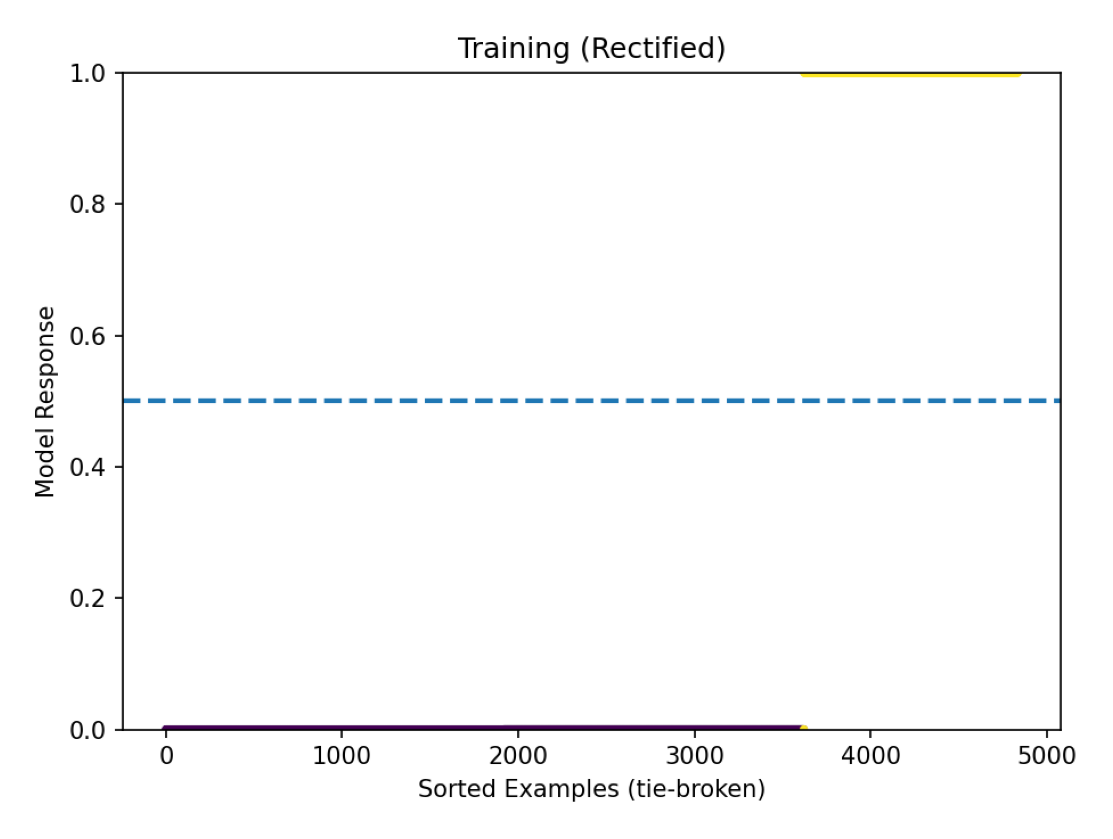

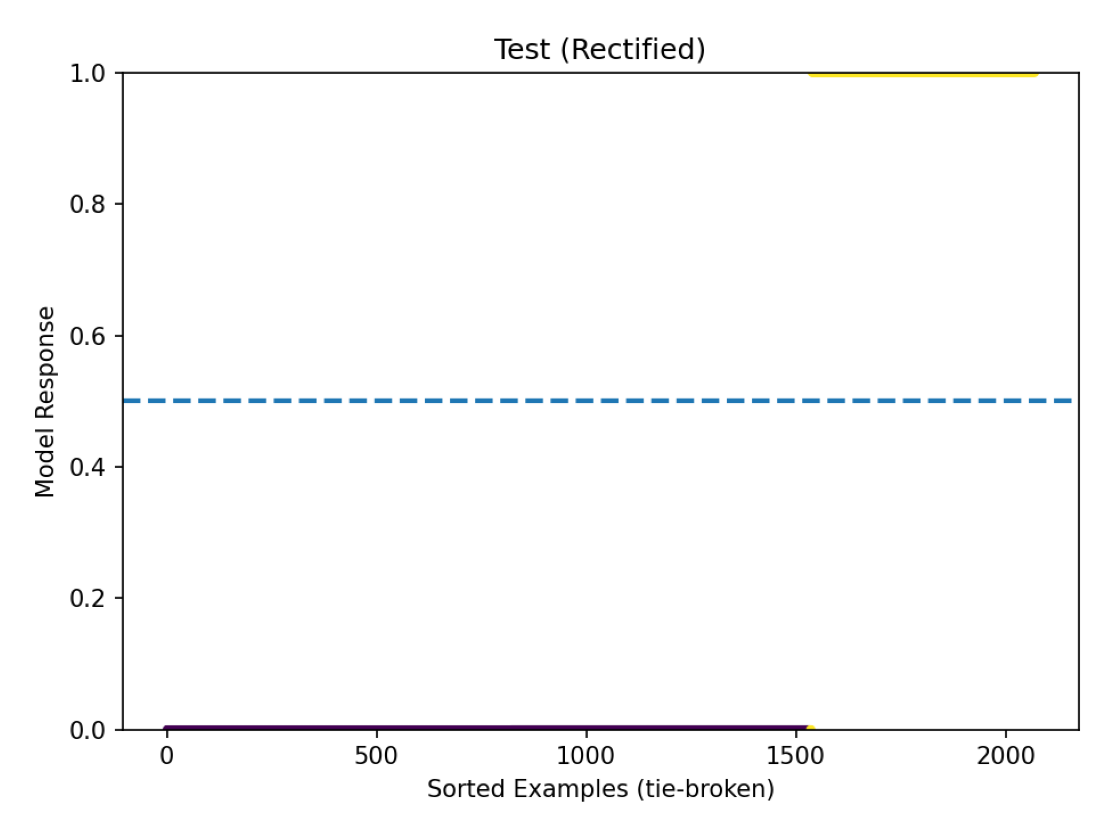

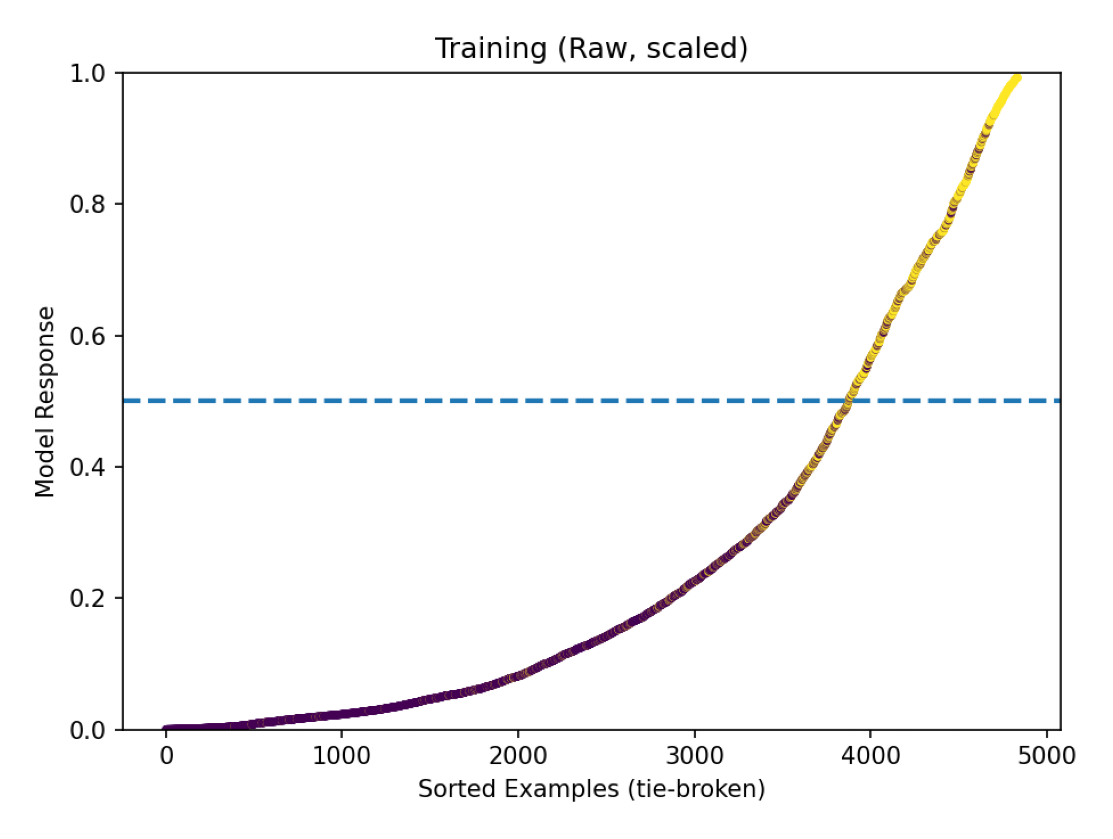

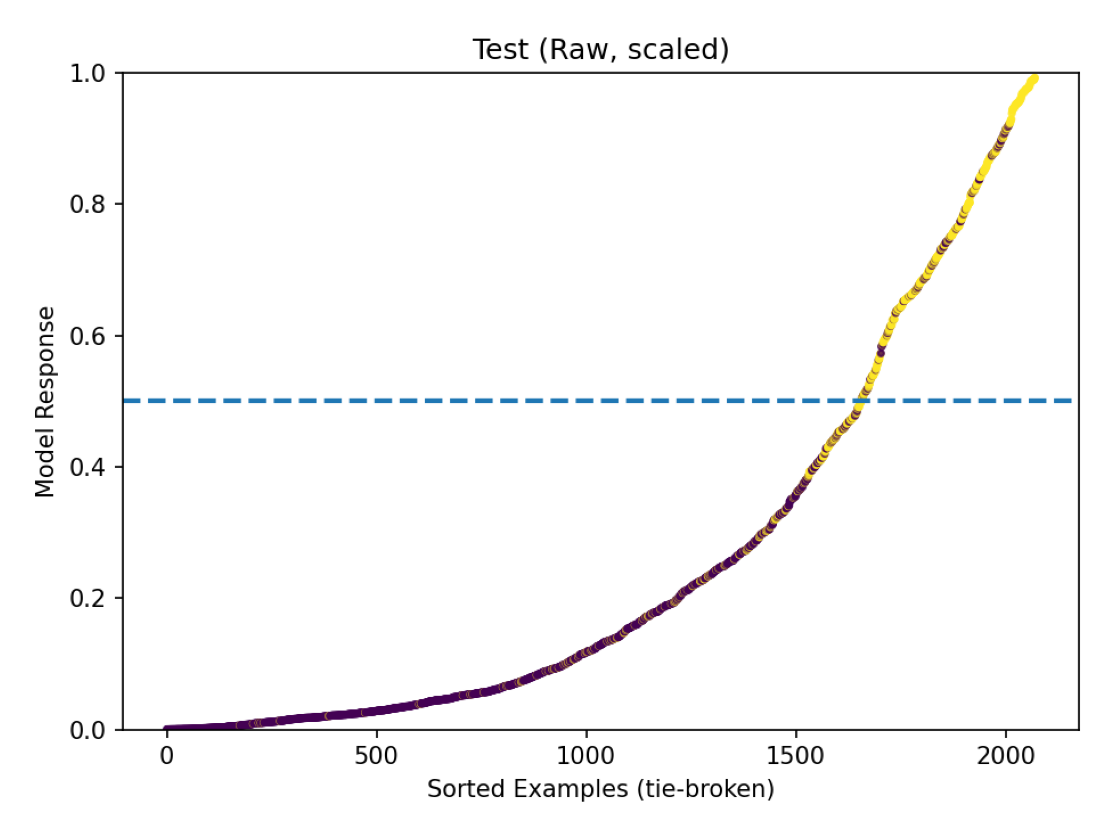

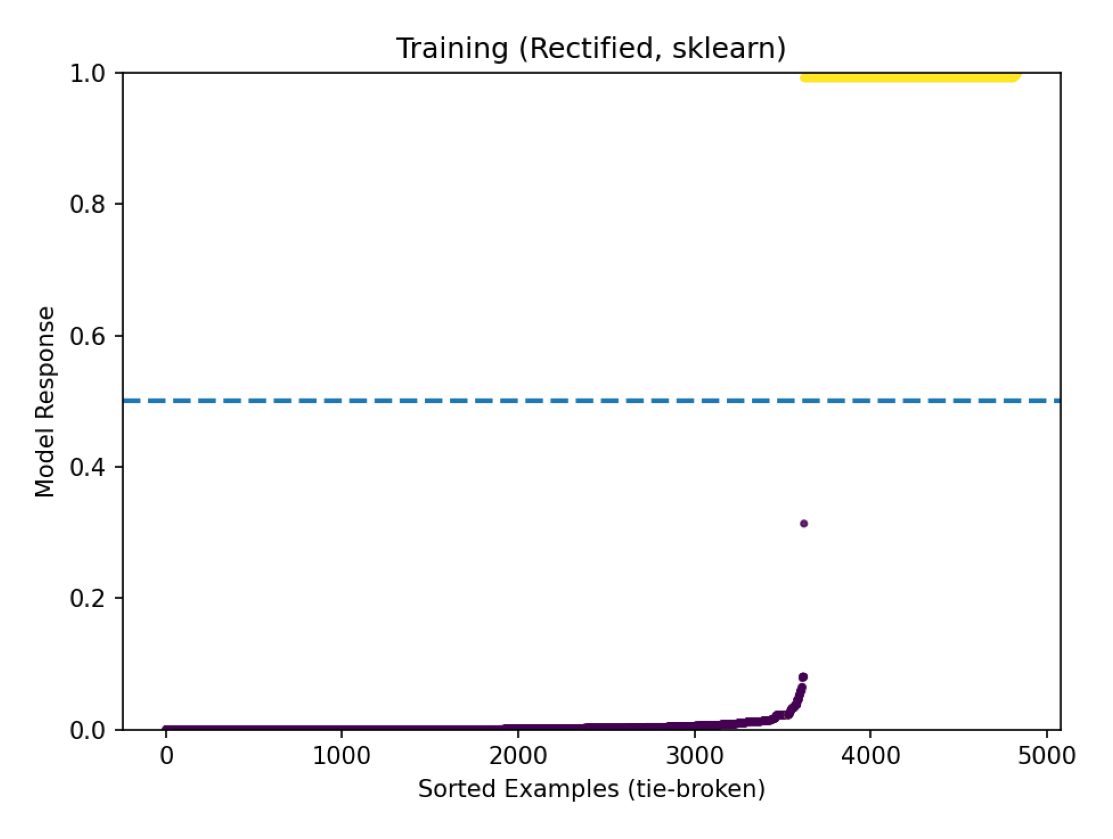

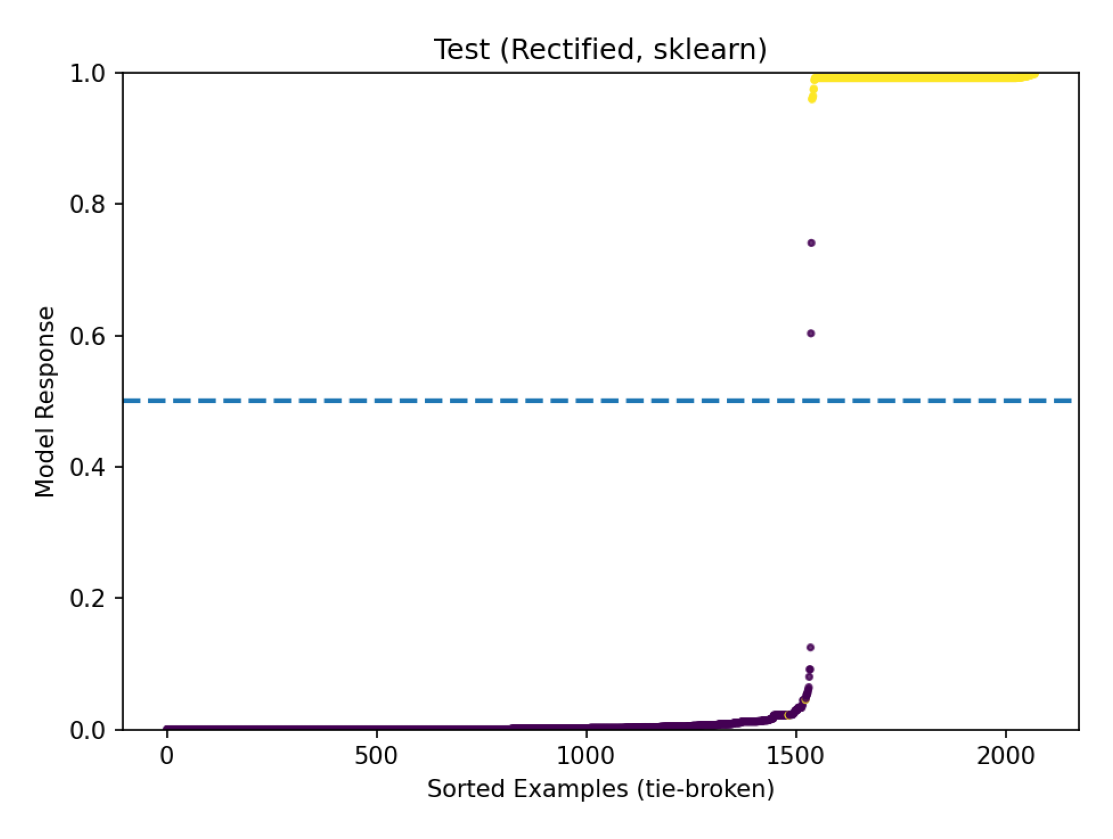

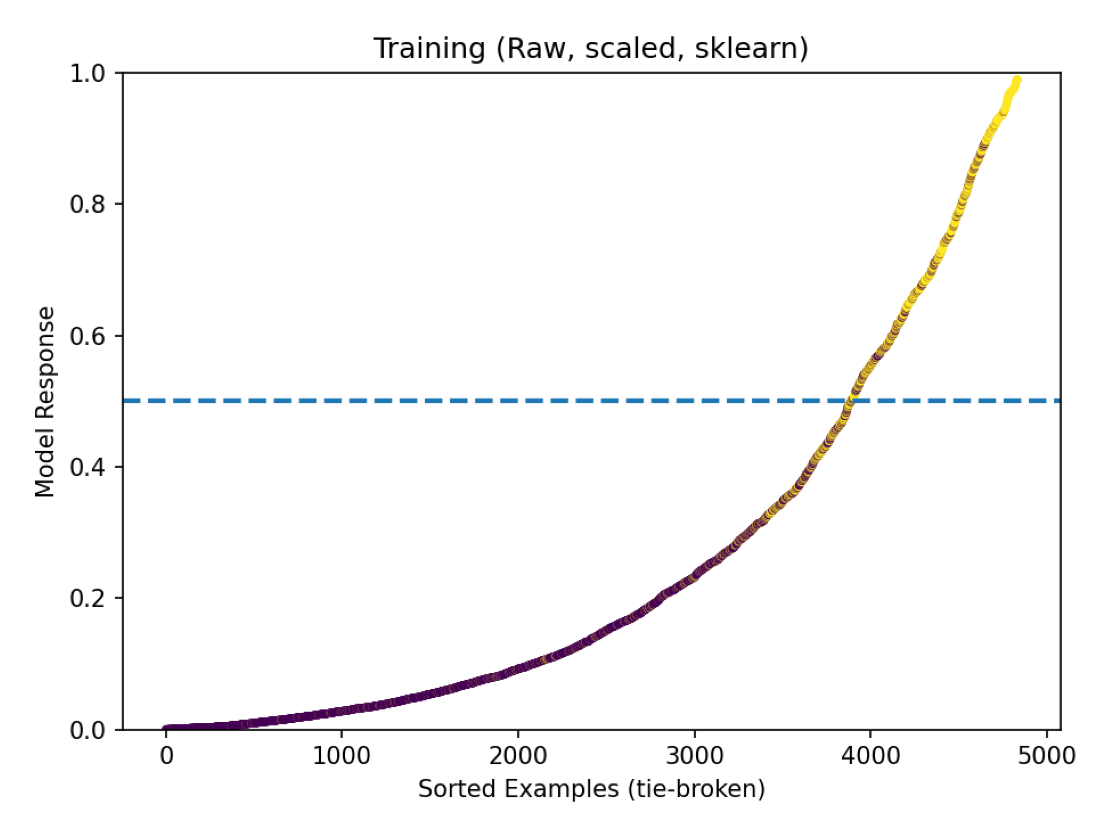

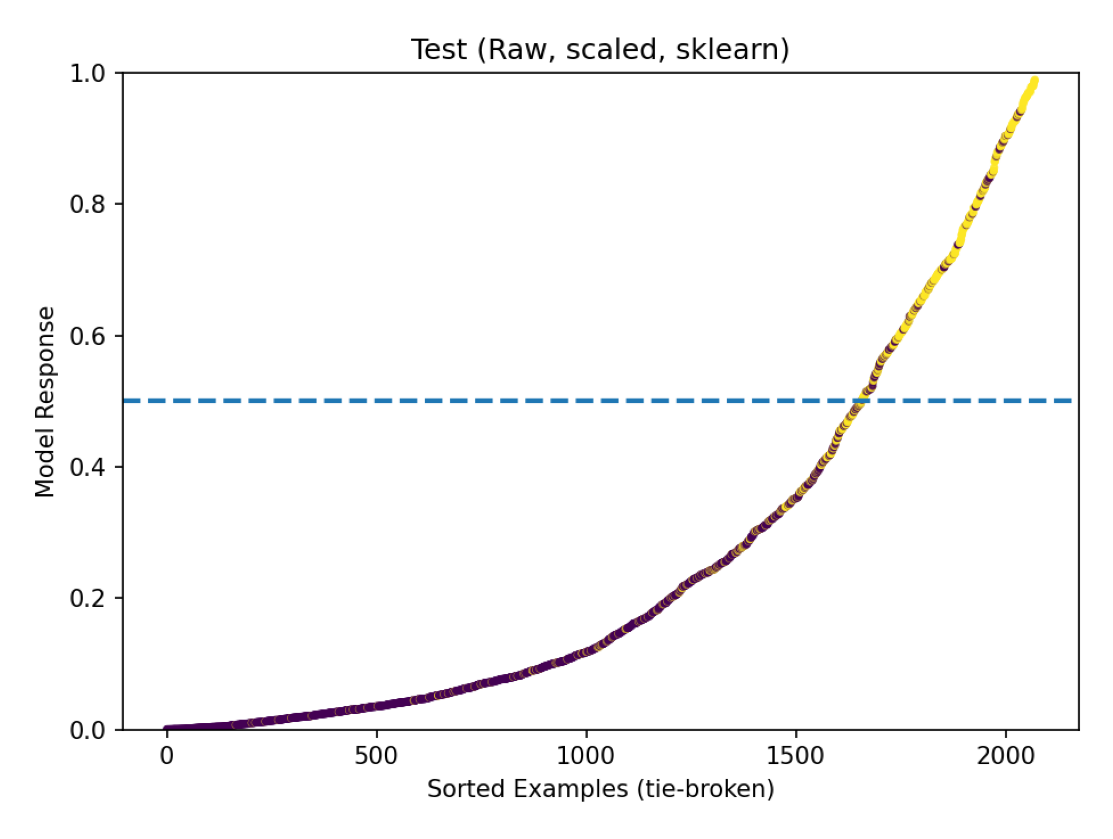

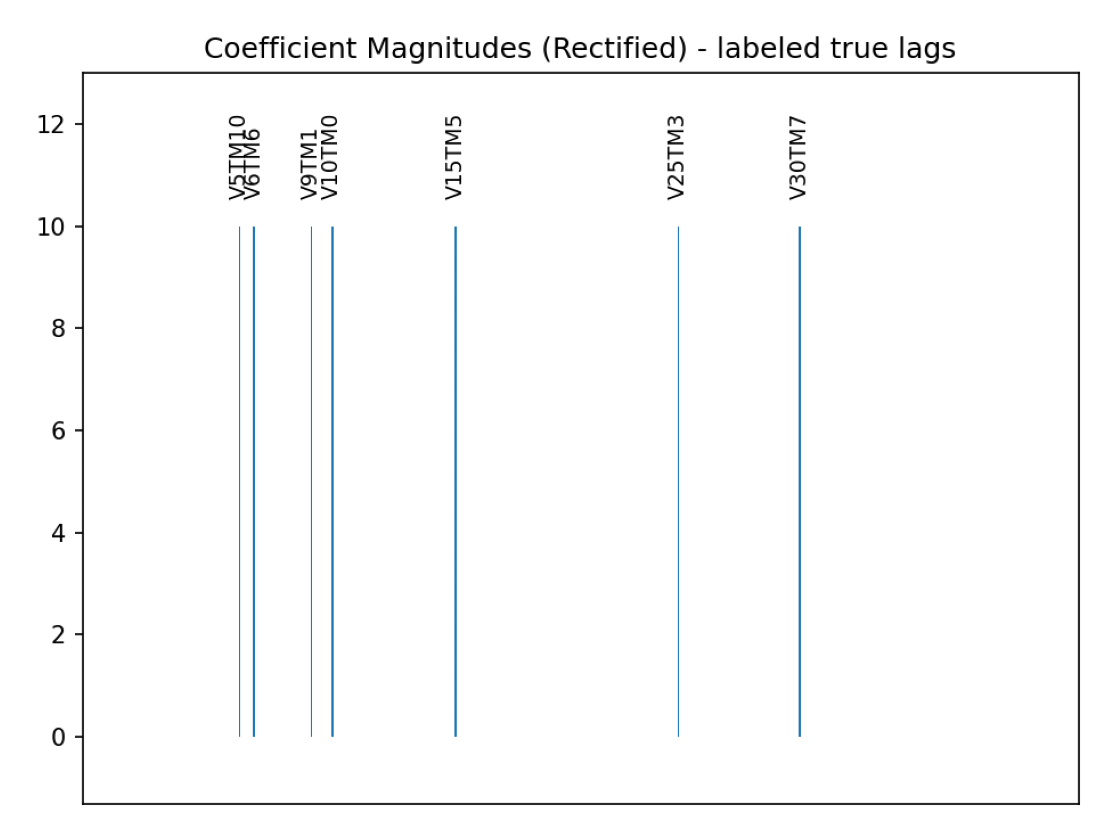

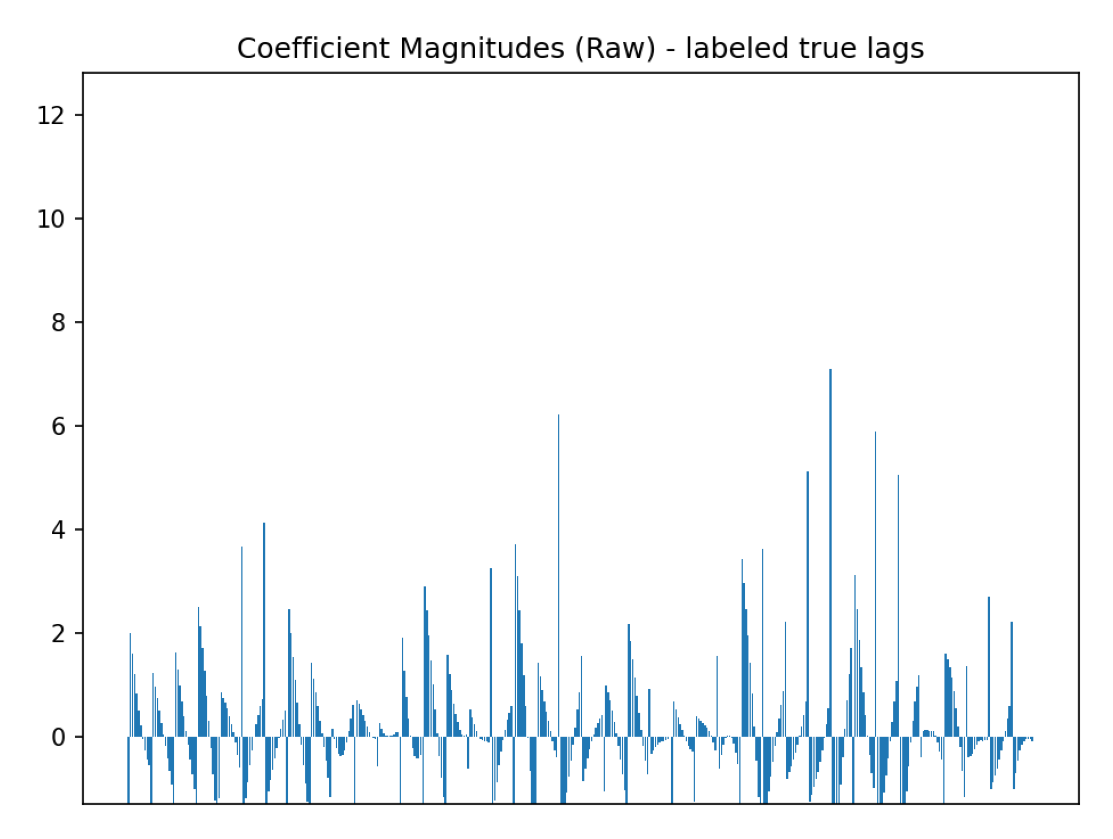

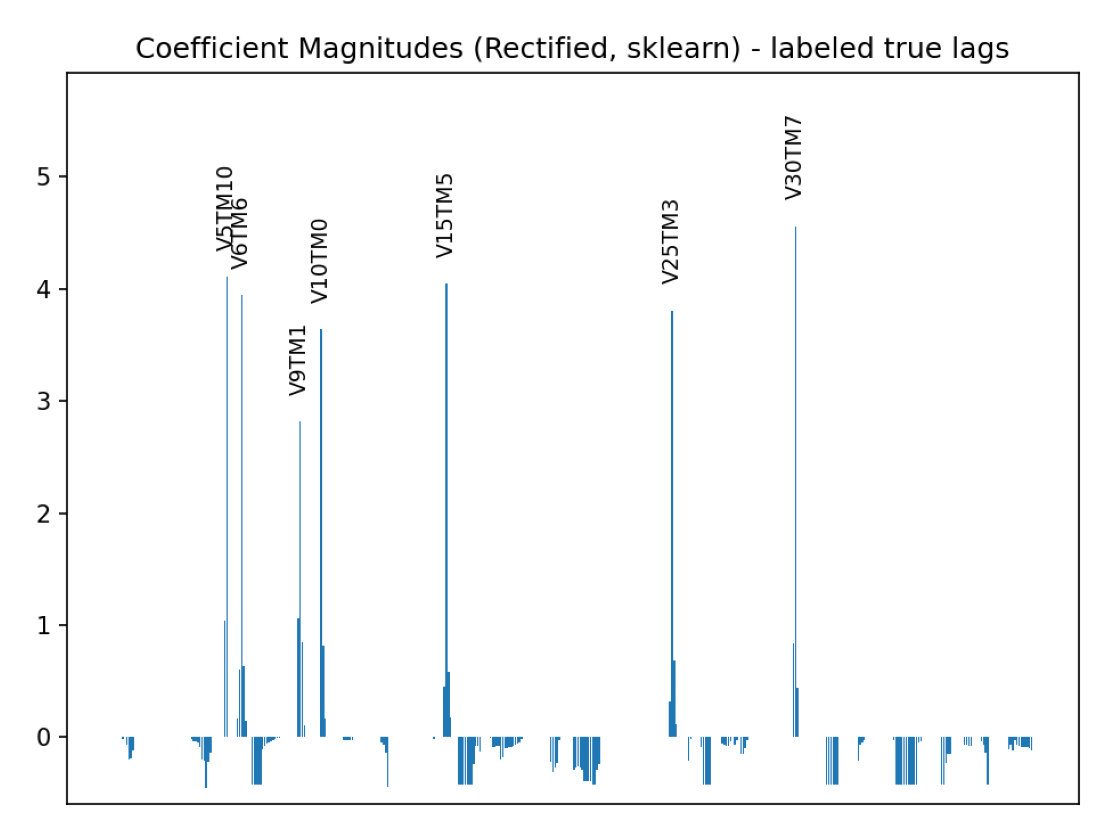

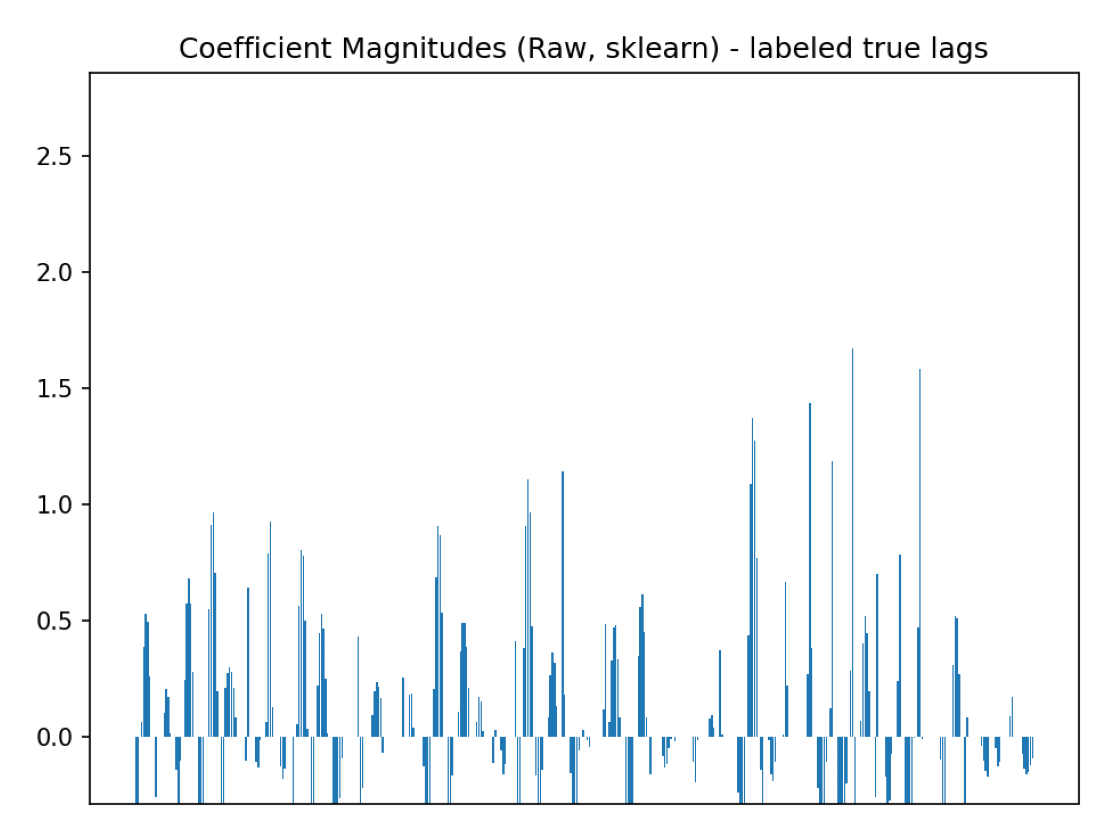

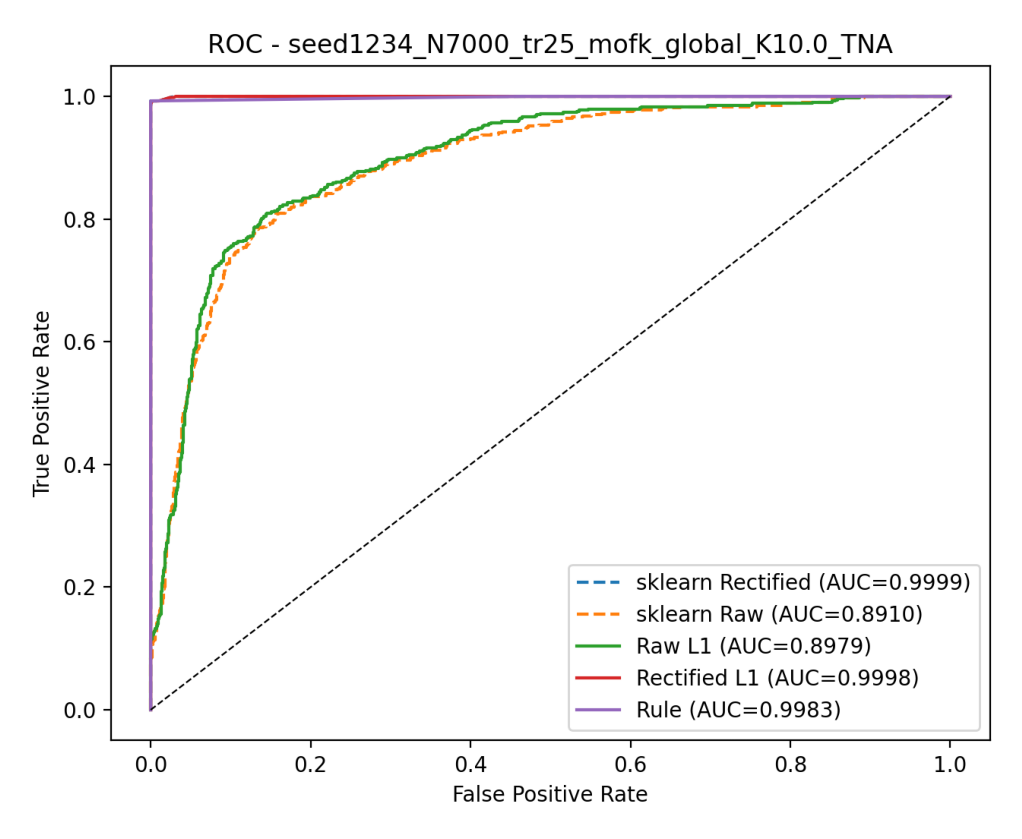

Loaded reference synthetic run from: C:\Users\jason\ODU\cutlass_demo\scripts\runs_new\seed1234_N7000_tr25_mofk_global_K10.0_TNA
Copied reference figures to: C:\Users\jason\ODU\dissertation\notebooks\Figures


In [8]:
import shutil

REFERENCE_RUN_ID = 'seed1234_N7000_tr25_mofk_global_K10.0_TNA'
REFERENCE_FIGURES = [
    'Training_Rectified.png',
    'Test_Rectified.png',
    'Training_Raw_scaled.png',
    'Test_Raw_scaled.png',
    'Training_Rectified_sklearn.png',
    'Test_Rectified_sklearn.png',
    'Training_Raw_scaled_sklearn.png',
    'Test_Raw_scaled_sklearn.png',
    'Coefficient_Magnitudes_Rectified_-_labeled_true_lags.png',
    'Coefficient_Magnitudes_Raw_-_labeled_true_lags.png',
    'Coefficient_Magnitudes_Rectified_sklearn_-_labeled_true_lags.png',
    'Coefficient_Magnitudes_Raw_sklearn_-_labeled_true_lags.png',
    'ROC_All_Models.png',
]

search_roots = [
    NOTEBOOKS_DIR.parent.parent / 'cutlass_demo',
    SCRIPTS_DIR.parent.parent / 'cutlass_demo',
    Path.cwd(),
]

reference_run_dir = None
for root in search_roots:
    candidate = root / 'scripts' / 'runs_new' / REFERENCE_RUN_ID
    if candidate.is_dir():
        reference_run_dir = candidate
        break

if reference_run_dir is None:
    raise FileNotFoundError(f'Could not find the reference run directory for {REFERENCE_RUN_ID}')

reference_fig_dir = reference_run_dir / 'figs'
reference_summary_path = reference_run_dir.parent / 'summary.csv'
if not reference_summary_path.exists():
    raise FileNotFoundError(f'Could not find reference summary at {reference_summary_path}')

summary_df = pd.read_csv(reference_summary_path)
summary_view = summary_df[summary_df['run_id'].astype(str).str.startswith(REFERENCE_RUN_ID)].copy()
display(summary_view)

for fig_name in REFERENCE_FIGURES:
    src = reference_fig_dir / fig_name
    if not src.exists():
        raise FileNotFoundError(f'Missing reference figure: {src}')
    dst = NOTEBOOK_FIGURES_DIR / fig_name
    shutil.copy2(src, dst)

    img = plt.imread(dst)
    height, width = img.shape[:2]
    aspect = width / max(height, 1)
    fig_width = 11.5
    fig_height = max(4.5, min(8.5, fig_width / max(aspect, 0.1)))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.imshow(img)
    ax.axis('off')
    fig.tight_layout()
    plt.show()

print('Loaded reference synthetic run from:', reference_run_dir)
print('Copied reference figures to:', NOTEBOOK_FIGURES_DIR)



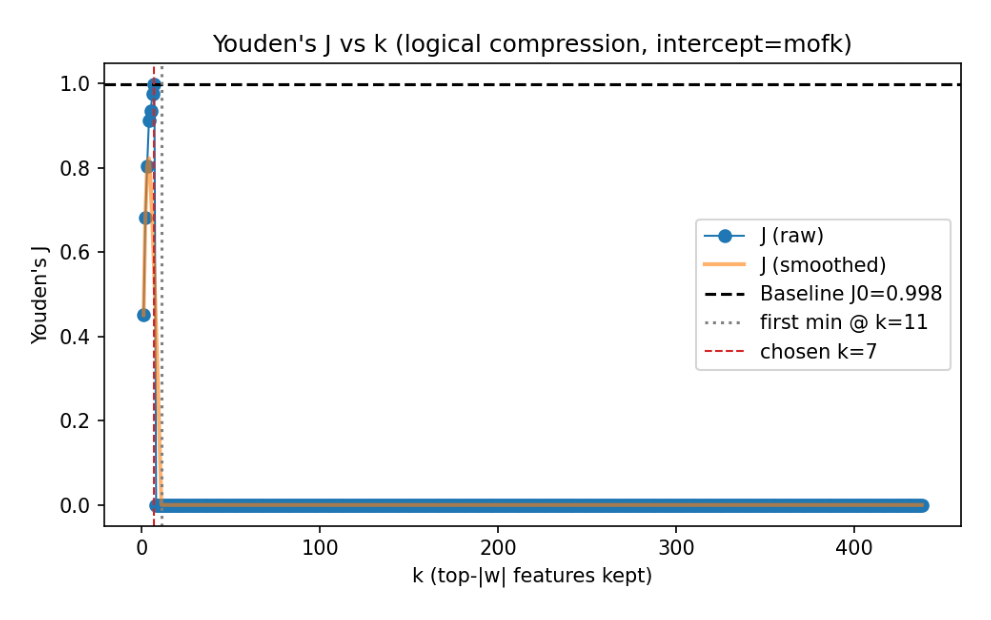

Displayed reference synthetic J-vs-k figure from: C:\Users\jason\ODU\cutlass_demo\scripts\runs_new\seed1234_N7000_tr25_mofk_global_K10.0_TNA\figs\logical_J_vs_k.png
Copied figure to: C:\Users\jason\ODU\dissertation\notebooks\Figures\synthetic_logical_J_vs_k.png


In [9]:
import shutil

reference_jvk_path = reference_fig_dir / 'logical_J_vs_k.png'
if not reference_jvk_path.exists():
    raise FileNotFoundError(f'Missing reference J-vs-k figure: {reference_jvk_path}')

j_curve_output_path = NOTEBOOK_FIGURES_DIR / 'synthetic_logical_J_vs_k.png'
shutil.copy2(reference_jvk_path, j_curve_output_path)

img = plt.imread(j_curve_output_path)
fig, ax = plt.subplots(figsize=(10.5, 6.3))
ax.imshow(img)
ax.axis('off')
fig.tight_layout()
plt.show()

print('Displayed reference synthetic J-vs-k figure from:', reference_jvk_path)
print('Copied figure to:', j_curve_output_path)

